# MNIST Feature Extraction, Classification & Generative Models

Image classification on MNIST built around hand-engineered frequency features, a
design-of-experiments study on a line-of-sight detection simulation, and a comparative
survey of modern generative sequence architectures.

## 1. MNIST Feature Extraction & Classification

Feature extraction and image classification on the [MNIST](https://www.openml.org/d/554)
handwritten-digit dataset:

- **Preprocessing & visualization** of the digit images (representative samples per class).
- **Feature engineering via the 2D Discrete Cosine Transform:** each 28×28 image is
  DCT-transformed, then horizontal / vertical / diagonal **directional frequency masks**
  select coefficients. For each direction, the top 20 eigenvectors (from an eigen-decomposition
  of the covariance matrix) are retained and concatenated into a 60-dimensional feature vector.
- **Classification & comparison:** a scikit-learn classifier and a **from-scratch SVM** on the
  DCT/eigen features, plus a **PyTorch CNN** trained on the raw pixels — comparing accuracy,
  training time, and why learned convolutional features outperform fixed DCT features.

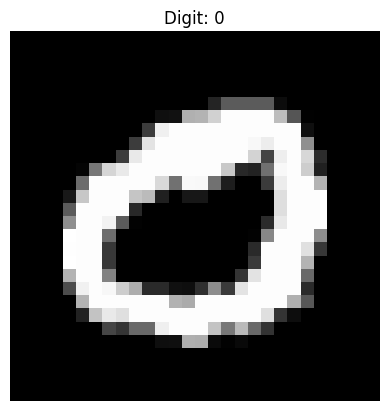

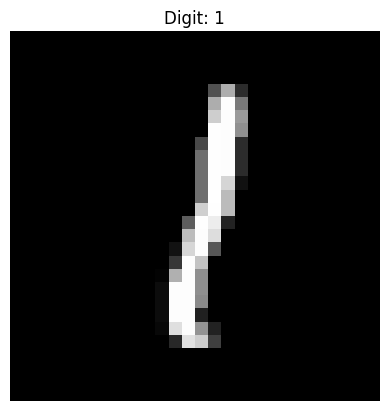

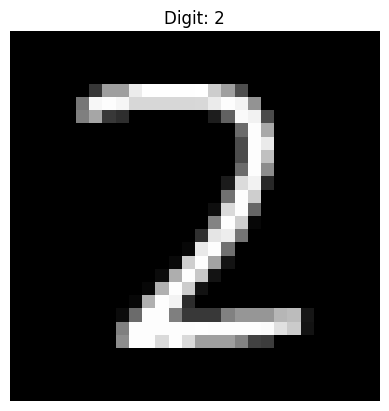

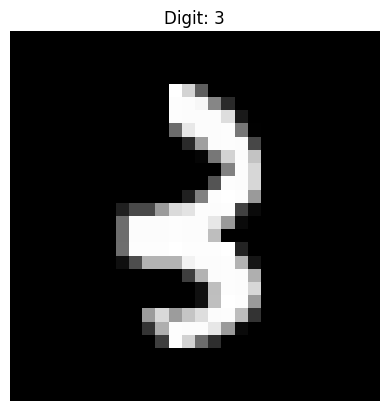

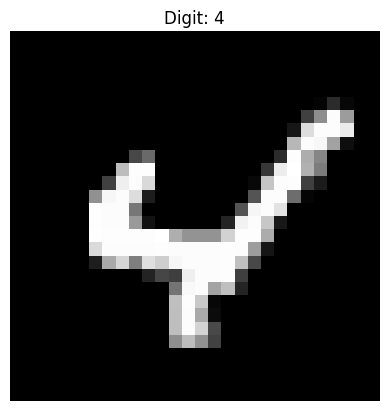

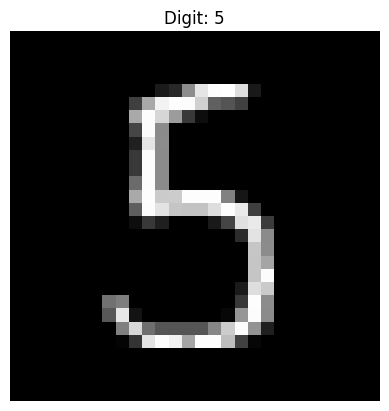

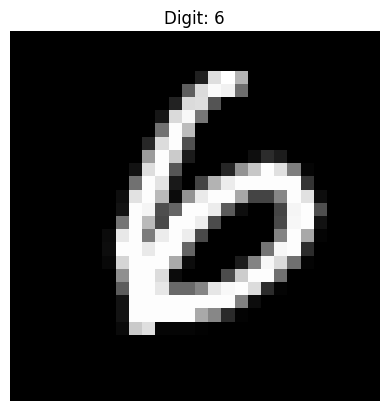

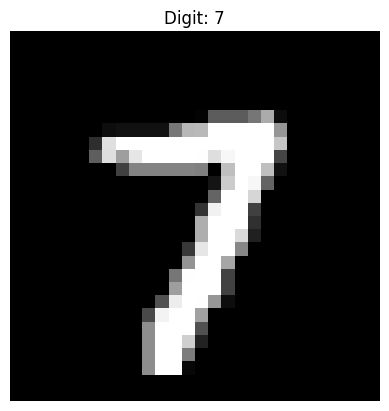

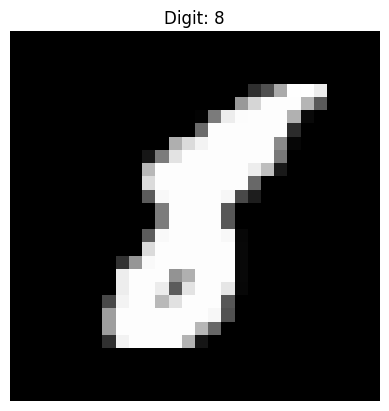

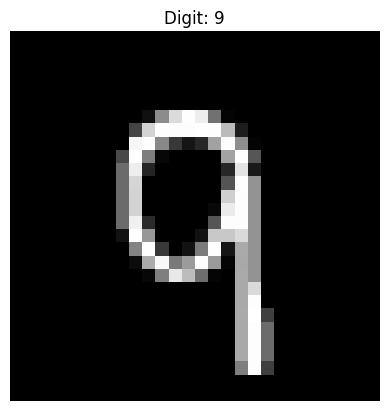

(1000, 784)
(1000,)
Unique classes present in the target matrix : ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


In [ ]:
# Q1

# PART 1

# 1. Load the dataset
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)

import numpy as np
import matplotlib.pyplot as plt

# 2. Display example images of each written number 0-9
targets = mnist['target'].astype(int)

for i in range(10):
  idxs = np.where(targets == i)[0]
  # print(idxs)
  random_idx = np.random.choice(idxs)
  # print(random_idx)

  random_image = np.array(mnist['data'].iloc[random_idx]).reshape(28, 28)

  plt.imshow(random_image, cmap='gray')
  plt.title(f"Digit: {i}")
  plt.axis('off')
  plt.show()


# 3. Create the final dataset where each diit class has atleast 100 samples
X, y = [], []
for i in range(10):
  idxs = np.where(targets == i)[0]

  random_100_idxs = np.random.choice(idxs, 100, replace = False)
  for idx in random_100_idxs:
    image = np.array(mnist['data'].iloc[idx])
    # print(image.shape)
    label = np.array(mnist['target'].iloc[idx])
    # print(label.shape)
    X.append(image)
    y.append(label)

X = np.array(X)
y = np.array(y)

indices = np.random.permutation(len(X))
X = X[indices]
y = y[indices]

print('Shape of the feature matrix :', X.shape)
print('Shape of the target matrix :', y.shape)

# showing proof that there are samples of each class in y
print('Unique classes present in the target matrix :', np.unique(y))

In [ ]:
# PART 2

from scipy.fftpack import dct
from numpy.linalg import eigh

def create_custom_dct_masks(size=28):
      h_mask = np.zeros((size, size), dtype=bool)
      v_mask = np.zeros((size, size), dtype=bool)
      d_mask = np.zeros((size, size), dtype=bool)

      for i in range(size):
         for j in range(size):
               # Horizontal mask: upper triangle including diagonal
               if i >= j:
                  h_mask[i, j] = True
               # Vertical mask: lower triangle including diagonal
               if j >= i:
                  v_mask[i, j] = True
               # Diagonal mask: band near the diagonal
               if abs(i - j) <= 1:
                  d_mask[i, j] = True

      return h_mask, v_mask, d_mask


def apply_2d_dct(images):
    dct_images = []
    for img in images:
        img_2d = img.reshape(28, 28)
        dct_2d = dct(dct(img_2d.T, norm='ortho').T, norm='ortho')
        dct_images.append(dct_2d)
    return np.array(dct_images)

def extract_directional_features(dct_images, mask):
    masked_features = []
    for dct_img in dct_images:
        masked = dct_img[mask]
        masked_features.append(masked)
    return np.array(masked_features)

def compute_top_eigen_features(features, num_components=20):
    mean_vec = np.mean(features, axis=0)
    centered = features - mean_vec
    cov_matrix = np.cov(centered, rowvar=False)
    eigvals, eigvecs = eigh(cov_matrix)
    top_vecs = eigvecs[:, -num_components:]  # last columns = top eigenvectors
    projected = centered @ top_vecs
    return projected

def generate_final_features(X):
    h_mask, v_mask, d_mask = create_custom_dct_masks()
    dct_images = apply_2d_dct(X)

    h_feats = extract_directional_features(dct_images, h_mask)
    v_feats = extract_directional_features(dct_images, v_mask)
    d_feats = extract_directional_features(dct_images, d_mask)

    h_proj = compute_top_eigen_features(h_feats)
    v_proj = compute_top_eigen_features(v_feats)
    d_proj = compute_top_eigen_features(d_feats)

    final_features = np.concatenate([h_proj, v_proj, d_proj], axis=1)  # shape: (n_samples, 60)
    return final_features

# Run it
X_final = generate_final_features(X)

print("Final dataset shape (60 features):", X_final.shape)

Final dataset shape (60 features): (1000, 60)


Random Forest Accuracy: 0.835


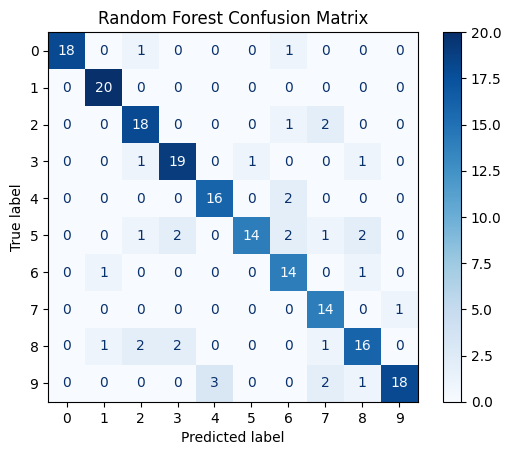

In [ ]:
# PART 3

# 1. Train a random supervised model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_final, y.astype(int), test_size=0.2, random_state=42)

# Train Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Accuracy and Confusion Matrix
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf).plot(cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

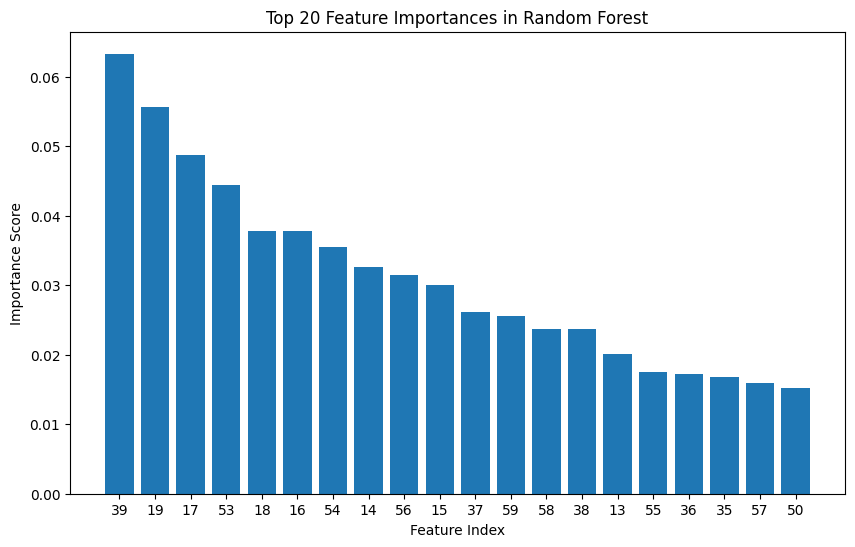

In [ ]:
importances = rf.feature_importances_  # Array of shape (n_features,)

# Optionally, sort them and display
indices = np.argsort(importances)[::-1]  # Descending order
top_k = 20  # Number of top features to display

plt.figure(figsize=(10, 6))
plt.title("Top 20 Feature Importances in Random Forest")
plt.bar(range(top_k), importances[indices[:top_k]], align="center")
plt.xticks(range(top_k), indices[:top_k])
plt.xlabel("Feature Index")
plt.ylabel("Importance Score")
plt.show()

Based on the plot above, feature 39 seems to be the most important. It is not exactly known what this feature is. Random Forests learn decisions at every node based on the metric (entropy or gini index). It creates ensembles of trees that learn these features and aggregates the results.

Custom SVM (Linear) Accuracy: 0.66


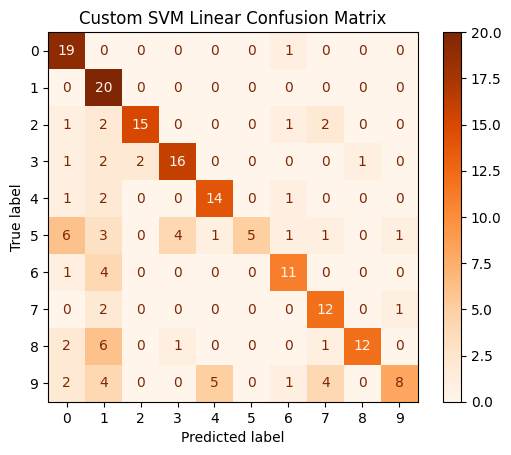

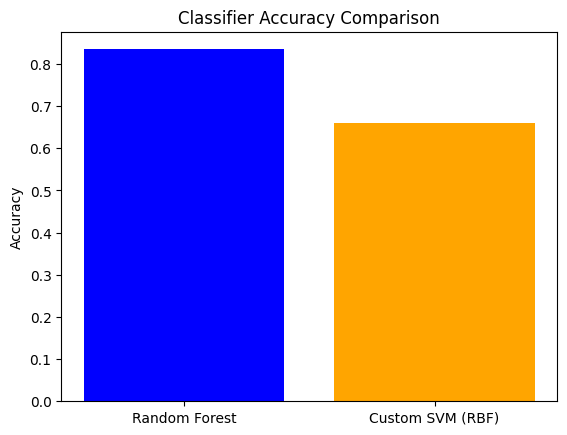

In [ ]:
from sklearn.preprocessing import LabelBinarizer

# SVM
from cvxopt import matrix, solvers

class SVM:
    def __init__(self, C=1.0, kernel = 'linear', gamma = 1.0):
        self.C = C
        self.kernel = kernel
        self.gamma = gamma

    def linear_kernel(self, x, y):
        return np.dot(x, y.T)

    def rbf_kernel(self, x, y):
        if x.ndim == 1:
            x = x[np.newaxis, :]
        if y.ndim == 1:
            y = y[np.newaxis, :]
        dists = np.linalg.norm(x[:, np.newaxis] - y, axis=2)**2
        return np.exp(-self.gamma * dists)

    def compute_kernel(self, X, Y):
        if self.kernel == 'linear':
            return self.linear_kernel(X, Y)
        elif self.kernel == 'rbf':
            return self.rbf_kernel(X, Y)
        else:
            raise ValueError("Unsupported kernel")

    def fit(self, X, y):
        n_samples, _ = X.shape
        y = y * 1.0
        y[y == 0] = -1  # convert to -1 and 1

        # K = np.dot(X, X.T)
        K = self.compute_kernel(X, X)

        P = matrix(np.outer(y, y) * K)
        q = matrix(-np.ones(n_samples))

        A = matrix(y.reshape(1, -1))
        b = matrix(0.0)

        G_std = np.diag(-np.ones(n_samples))
        h_std = np.zeros(n_samples)

        G_slack = np.identity(n_samples)
        h_slack = np.ones(n_samples) * self.C

        G = matrix(np.vstack((G_std, G_slack)))
        h = matrix(np.hstack((h_std, h_slack)))

        solvers.options['show_progress'] = False
        solution = solvers.qp(P, q, G, h, A, b)

        alpha = np.ravel(solution['x'])
        sv = alpha > 1e-5
        self.alpha = alpha[sv]
        self.sv_X = X[sv]
        self.sv_y = y[sv]

        self.w = np.dot((self.alpha * self.sv_y), self.sv_X)
        self.b = np.mean(self.sv_y - np.dot(self.sv_X, self.w))

    def project(self, X):
        return np.dot(X, self.w) + self.b

    def predict(self, X):
        return (self.project(X) >= 0).astype(int)

def train_custom_svm_one_vs_rest(X_train, y_train, X_test, kernel='linear', gamma=1.0):
    classifiers = []
    y_train_bin = LabelBinarizer().fit_transform(y_train)  # shape: (n_samples, 10)

    predictions = []
    for i in range(10):
        svm = SVM(C=1.0, kernel=kernel, gamma=gamma)
        svm.fit(X_train, y_train_bin[:, i])
        pred = svm.project(X_test)  # Use raw decision score
        predictions.append(pred)
        classifiers.append(svm)

    predictions = np.array(predictions)  # shape: (10, n_samples)
    y_pred = np.argmax(predictions, axis=0)
    return y_pred, classifiers

# Linear kernel
y_pred_custom_linear, _ = train_custom_svm_one_vs_rest(X_train, y_train, X_test, kernel='rbf')
acc_custom_linear = accuracy_score(y_test, y_pred_custom_linear)
print("Custom SVM (Linear) Accuracy:", acc_custom_linear)

cm_custom_linear = confusion_matrix(y_test, y_pred_custom_linear)
ConfusionMatrixDisplay(cm_custom_linear).plot(cmap='Oranges')
plt.title("Custom SVM Linear Confusion Matrix")
plt.show()

models = ['Random Forest', 'Custom SVM (RBF)']
accuracies = [acc_rf, acc_custom_linear]

# 3. comparing accuracies
plt.bar(models, accuracies, color=['blue', 'orange'])
plt.ylabel('Accuracy')
plt.title('Classifier Accuracy Comparison')
plt.show()


In terms of performance, Random Forests acheives higher accuracy and takes lesser time to tran compared to the custom implementation of SVM. The random forests model is more flexible implementation wise. The results differ since Random forest is an ensemble model, it interprets multiple results/opinions unlike SVM which is a singular model.

In [ ]:
# 4. CNN
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

# Normalize and reshape X for CNN
X_cnn = X.reshape(-1, 1, 28, 28).astype(np.float32) / 255.0
y_cnn = y.astype(np.int64)

# Train-test split
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(X_cnn, y_cnn, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
train_dataset = TensorDataset(torch.tensor(X_train_cnn), torch.tensor(y_train_cnn))
test_dataset = TensorDataset(torch.tensor(X_test_cnn), torch.tensor(y_test_cnn))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),  # output: 16x28x28
            nn.LeakyReLU(),
            nn.MaxPool2d(2, 2),              # output: 16x14x14
            nn.Conv2d(16, 32, 3, padding=1), # output: 32x14x14
            nn.LeakyReLU(),
            nn.MaxPool2d(2, 2)               # output: 32x7x7
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*7*7, 128),
            nn.LeakyReLU(),
            nn.Linear(128, 10)  # 10 digit classes
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
for epoch in range(10):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")


from sklearn.metrics import accuracy_score

model.eval()
y_pred_cnn, y_true = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        y_pred_cnn.extend(preds)
        y_true.extend(labels.numpy())

cnn_accuracy = accuracy_score(y_true, y_pred_cnn)
print(f"CNN Test Accuracy: {cnn_accuracy:.4f}")

Epoch 1, Loss: 2.1621
Epoch 2, Loss: 1.5266
Epoch 3, Loss: 0.8592
Epoch 4, Loss: 0.6079
Epoch 5, Loss: 0.4454
Epoch 6, Loss: 0.3623
Epoch 7, Loss: 0.3046
Epoch 8, Loss: 0.2534
Epoch 9, Loss: 0.2167
Epoch 10, Loss: 0.1931
CNN Test Accuracy: 0.8900


In [ ]:
# 5. CNN vs DCT-based models

print(f"CNN Accuracy: {cnn_accuracy:.4f}")
print(f"Random Forest Accuracy: {acc_rf:.4f}")
print(f"Custom SVM (RBF) Accuracy: {acc_custom_linear:.4f}")

CNN Accuracy: 0.8900
Random Forest Accuracy: 0.8350
Custom SVM (RBF) Accuracy: 0.6600


The reason why CNNs outperform DCT based models is that the Conv layers learn useful features and aren't restrictive like the DCT features. These features could be intuitively thought of size or shape or location etc. These features are refined by the repeated use of CONV layers making them more robust compared to other features. Images often carry complex relationships and features and only a model that is complex enough can learn these representations properly.

## 2. Design of Experiments: Line-of-Sight Detection

A design-of-experiments study on a physics simulation of air-to-ground **line-of-sight (LOS)
detection**. The simulation places a ground object within a small geographic bounding box and
an aircraft within a larger one, steps the aircraft's motion over time, and checks at each step
whether LOS exists (great-circle distance vs. the sum of horizon distances). The binary
**target** records detection (`0` = LOS occurred, `1` = no LOS).

The analysis builds on the simulation output: forming hypotheses about which parameters drive
detection, training a **Random Forest** classifier, running **ANOVA** and **logistic regression**
with `statsmodels`, and reconciling feature importances against statistical significance.

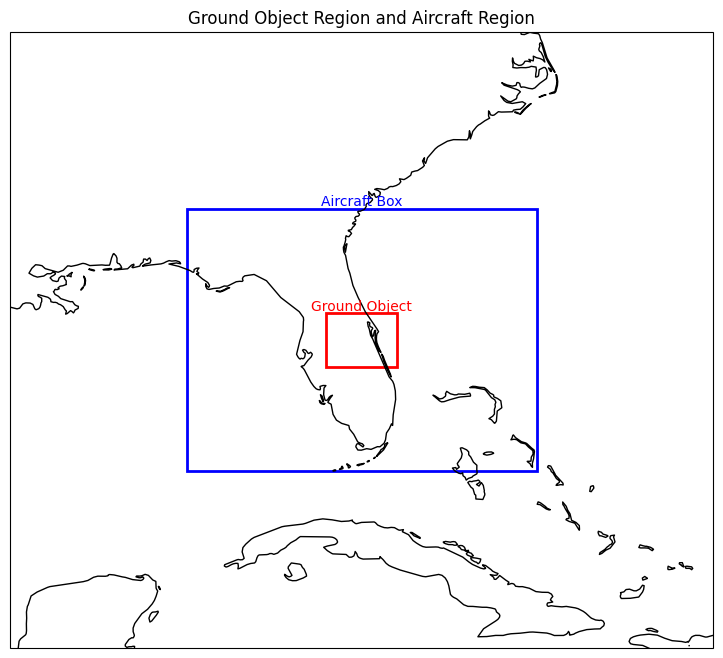

In [15]:
import math
import random
import matplotlib.pyplot as plt
!pip install cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import pandas as pd

# -----------------------
# Define the Ground Object box (ground object region)
# -----------------------
ground_lon_min, ground_lat_min = -82, 27.5
ground_lon_max, ground_lat_max = -80, 29.0
ground_width = ground_lon_max - ground_lon_min  # 2.0 degrees
ground_height = ground_lat_max - ground_lat_min   # 1.5 degrees

# Compute the center of the ground box
center_lon = (ground_lon_min + ground_lon_max) / 2
center_lat = (ground_lat_min + ground_lat_max) / 2

# -----------------------
# Define the Aircraft bounding box (30% smaller than the 50x area box)
# -----------------------
# Scale up dimensions for a 50x area then reduce by 30%
scale_factor = 50**0.5
aircraft_width = ground_width * scale_factor * 0.7
aircraft_height = ground_height * scale_factor * 0.7

# Center the aircraft box on the ground box center.
aircraft_lon_min = center_lon - aircraft_width / 2
aircraft_lon_max = center_lon + aircraft_width / 2
aircraft_lat_min = center_lat - aircraft_height / 2
aircraft_lat_max = center_lat + aircraft_height / 2

# -----------------------
# Visualization: Plotting Both Boxes
# -----------------------
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add geographic features.
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Draw the Ground Object box (red).
ground_rect = mpatches.Rectangle(
    (ground_lon_min, ground_lat_min),
    ground_width,
    ground_height,
    linewidth=2,
    edgecolor='red',
    facecolor='none',
    transform=ccrs.PlateCarree()
)
ax.add_patch(ground_rect)
ax.text((ground_lon_min + ground_lon_max) / 2, ground_lat_max,
        "Ground Object", color='red',
        ha='center', va='bottom', transform=ccrs.PlateCarree())

# Draw the Aircraft bounding box (blue).
aircraft_rect = mpatches.Rectangle(
    (aircraft_lon_min, aircraft_lat_min),
    aircraft_width,
    aircraft_height,
    linewidth=2,
    edgecolor='blue',
    facecolor='none',
    transform=ccrs.PlateCarree()
)
ax.add_patch(aircraft_rect)
ax.text((aircraft_lon_min + aircraft_lon_max) / 2, aircraft_lat_max,
        "Aircraft Box", color='blue',
        ha='center', va='bottom', transform=ccrs.PlateCarree())

# Set the extent to show both boxes with a margin.
margin_lon = 5
margin_lat = 5
ax.set_extent([aircraft_lon_min - margin_lon, aircraft_lon_max + margin_lon,
               aircraft_lat_min - margin_lat, aircraft_lat_max + margin_lat],
              crs=ccrs.PlateCarree())

plt.title("Ground Object Region and Aircraft Region")
plt.show()


In [16]:
import math
import random
import pandas as pd

# Earth's radius in meters
R = 6371000

# Simulation parameters
total_time = 3600  # seconds (1 hour)
dt = 10            # time step in seconds
num_steps = total_time // dt

# Number of simulation runs
num_runs = 10000

# -----------------------
# Helper Functions
# -----------------------
def haversine(lat1, lon1, lat2, lon2):
    """Calculate the great-circle distance between two points (in meters)."""
    lat1_rad, lon1_rad = math.radians(lat1), math.radians(lon1)
    lat2_rad, lon2_rad = math.radians(lat2), math.radians(lon2)
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    a = math.sin(dlat/2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon/2)**2
    c = 2 * math.asin(math.sqrt(a))
    return R * c

def update_position(lat, lon, speed, heading, dt):
    """
    Update position based on current lat/lon, speed (m/s), heading (degrees),
    and time step dt. Uses a simple spherical approximation.
    """
    distance = speed * dt
    heading_rad = math.radians(heading)
    delta_north = distance * math.cos(heading_rad)
    delta_east = distance * math.sin(heading_rad)
    delta_lat = (delta_north / R) * (180 / math.pi)
    delta_lon = (delta_east / (R * math.cos(math.radians(lat)))) * (180 / math.pi)
    new_lat = lat + delta_lat
    new_lon = lon + delta_lon
    new_lon = (new_lon + 180) % 360 - 180  # normalize longitude
    new_lat = max(min(new_lat, 90), -90)   # constrain latitude
    return new_lat, new_lon

def horizon_distance(alt):
    """
    Calculate the horizon distance (in meters) for a given altitude 'alt'
    using the approximation: distance ≈ √(2 * R * alt)
    """
    return math.sqrt(2 * R * alt)

# -----------------------
# Simulation Function
# -----------------------
def simulate_run():
    # Choose a random ground object location within the ground box.
    ground_lon = random.uniform(ground_lon_min, ground_lon_max)
    ground_lat = random.uniform(ground_lat_min, ground_lat_max)
    ground_alt = 1.5  # observer height in meters

    # Choose a random aircraft initial position within the aircraft bounding box.
    init_plane_lat = random.uniform(aircraft_lat_min, aircraft_lat_max)
    init_plane_lon = random.uniform(aircraft_lon_min, aircraft_lon_max)

    # Randomly select the aircraft altitude between 150 ft and 65,000 ft (converted to meters).
    plane_alt = random.uniform(150 * 0.3048, 65000 * 0.3048)

    # Aircraft speed and heading.
    plane_speed = 250  # m/s (~900 km/h)
    plane_heading = random.uniform(0, 360)  # degrees

    # Set initial aircraft position.
    plane_lat = init_plane_lat
    plane_lon = init_plane_lon

    # Flag for line-of-sight occurrence.
    los_occurred = False

    for step in range(int(num_steps) + 1):
        # Calculate the great-circle distance between ground object and aircraft.
        distance = haversine(ground_lat, ground_lon, plane_lat, plane_lon)
        # Calculate horizon distances.
        d_ground = horizon_distance(ground_alt)
        d_plane = horizon_distance(plane_alt)
        # If LOS exists at this timestep, flag it.
        if distance <= (d_ground + d_plane):
            los_occurred = True
            break
        # Update aircraft position.
        plane_lat, plane_lon = update_position(plane_lat, plane_lon, plane_speed, plane_heading, dt)

    # If LOS occurred at least once, target is 0, otherwise 1.
    target = 0 if los_occurred else 1

    return {
        "ground_lat": ground_lat,
        "ground_lon": ground_lon,
        "ground_alt": ground_alt,
        "init_plane_lat": init_plane_lat,
        "init_plane_lon": init_plane_lon,
        "plane_alt": plane_alt,
        "plane_speed": plane_speed,
        "plane_heading": plane_heading,
        "target": target
    }

# -----------------------
# Run the Simulation and Save Results in a DataFrame
# -----------------------
results = [simulate_run() for _ in range(num_runs)]
df = pd.DataFrame(results)

# Calculate the fraction of runs with target = 1 (i.e. no LOS ever occurred)
fraction_no_los = df["target"].mean()
print(f"Fraction of runs with no LOS (target=1): {fraction_no_los:.4f}")
print("\nDataFrame head:")
print(df.head())


Fraction of runs with no LOS (target=1): 0.3895

DataFrame head:
   ground_lat  ground_lon  ground_alt  init_plane_lat  init_plane_lon  \
0   27.760786  -80.897816         1.5       26.575733      -85.389459   
1   28.268014  -81.485502         1.5       29.682962      -78.607960   
2   28.958429  -81.515513         1.5       27.418282      -83.758600   
3   28.349906  -80.595404         1.5       27.168312      -78.933548   
4   27.764899  -81.925598         1.5       28.853313      -81.899943   

      plane_alt  plane_speed  plane_heading  target  
0   2942.815490          250     154.622417       1  
1  10965.786003          250     292.529590       0  
2   9672.847756          250     283.750678       0  
3  16073.853870          250     251.447902       0  
4   2889.804425          250     229.496069       0  


### Hypothesis & simulation summary

The ground object is randomly placed within a tiny rectangular region bounded by latitude and longitude (the red box on the map). The airplane begins at a random point within a much bigger bounding box (the blue box), which is 50 times larger in area than the ground region but scaled down by 30%.
At each time step, the aircraft's position is updated based on its speed and direction.
For each updated position, the simulation computes:

  - The great circle distance between the aircraft and the ground object.
  - The horizon distance between the airplane (depending on height) and the ground object.

If the actual distance is less than the total of their horizon distances, a line of sight exists. If LOS is detected at any point throughout the experiment, it terminates early.

The target variable serves as the label:
  - 0 indicates that LOS happened at least once throughout the flight.
  - 1 indicates no LOS happened at any stage.

Hypothesis:
Aircraft altitude will have the biggest impact on LOS detection.

  - The higher the aircraft's height, the larger the horizon distance, allowing it to "see" further along the Earth's curvature.
  - This increases the chances of LOS with the ground object.
  - On the other hand, slight variations in heading or longitude will probably cause the aircraft's trajectory to vary, but they won't significantly impact the range of vision.

Training Accuracy: 1.000
Testing Accuracy: 0.913


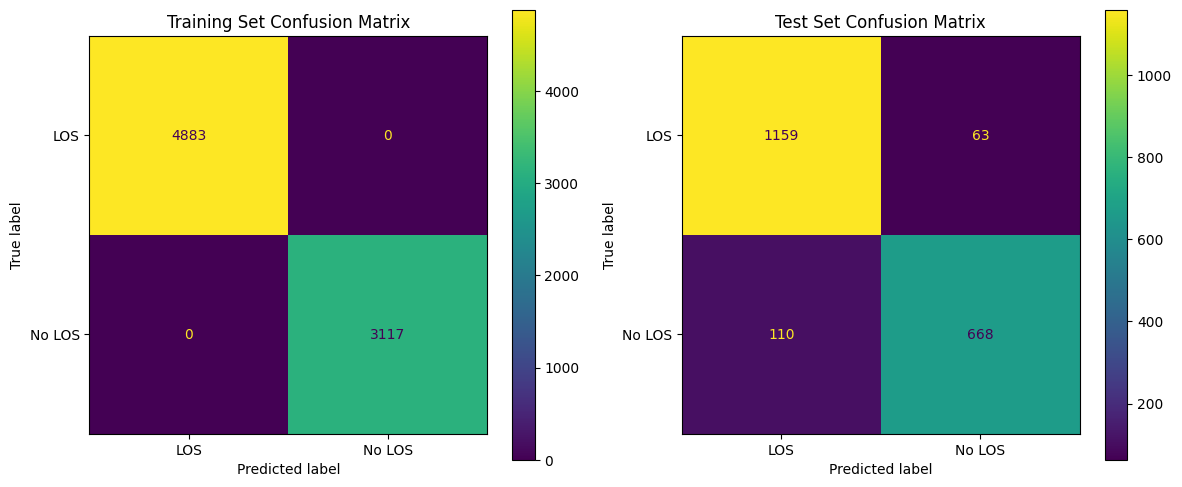

In [17]:
# PART 2

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Separate features and target
X = df.drop(columns=['target'])
y = df['target']

# 2. Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train Random Forest classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# 4. Evaluate model
y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_acc:.3f}")
print(f"Testing Accuracy: {test_acc:.3f}")

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axes[0], display_labels=["LOS", "No LOS"])
axes[0].set_title("Training Set Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, ax=axes[1], display_labels=["LOS", "No LOS"])
axes[1].set_title("Test Set Confusion Matrix")

plt.tight_layout()
plt.show()


In [19]:
print(clf.feature_importances_)
print(clf.feature_names_in_)

[0.07588773 0.08686527 0.         0.15498752 0.23738094 0.3104847
 0.         0.13439384]
['ground_lat' 'ground_lon' 'ground_alt' 'init_plane_lat' 'init_plane_lon'
 'plane_alt' 'plane_speed' 'plane_heading']


### Discussion

We initally hypothized that plane alttitude would be of high importance in this task. Based on the feature importances printed above, this claim is true. The model seems to slighly overfit since it makes some missclassifications on the test set but the overall accuracy on both the train and test set is high. The overall performance of the model aligns with our expectations.

In [20]:
# PART 3

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

# Combine training data into one DataFrame
train_df = X_train.copy()
train_df['target'] = y_train

# 1. Fit an OLS model
ols_model = smf.ols(formula='target ~ ground_lat + ground_lon + ground_alt + init_plane_lat + init_plane_lon + plane_alt + plane_speed + plane_heading', data=train_df).fit()

# Generate ANOVA table
anova_results = anova_lm(ols_model)
print("\nANOVA Table:")
print(anova_results)

# 2. Fit a logistic regression model
logit_model = smf.logit(formula='target ~ ground_lat + ground_lon + ground_alt + init_plane_lat + init_plane_lon + plane_alt + plane_speed + plane_heading', data=train_df).fit()

# Logistic regression summary
print("\nLogistic Regression Summary:")
print(logit_model.summary())



ANOVA Table:
                    df       sum_sq     mean_sq            F    PR(>F)
ground_lat         1.0     1.587881    1.587881     8.588137  0.003393
ground_lon         1.0     1.291701    1.291701     6.986231  0.008230
ground_alt         1.0     0.147118    0.147118     0.795697  0.372410
init_plane_lat     1.0     0.061707    0.061707     0.333748  0.563477
init_plane_lon     1.0     0.150860    0.150860     0.815934  0.366399
plane_alt          1.0   421.173101  421.173101  2277.936324  0.000000
plane_speed        1.0     0.001202    0.001202     0.006498  0.935752
plane_heading      1.0     0.297190    0.297190     1.607365  0.204899
Residual        7993.0  1477.844909    0.184892          NaN       NaN
Optimization terminated successfully.
         Current function value: 0.547393
         Iterations 9

Logistic Regression Summary:
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:        

### Statistical significance (ANOVA & logistic regression)

The ANOVA table shows `ground_lat`, `ground_lon`, and `plane_alt` are statistically significant
predictors of the LOS target, with p-values well below 0.05. The logistic regression agrees on
these three.

### Hypothesis vs. results

The initial hypothesis was that plane altitude would be the strongest predictor of LOS. The
ANOVA and logistic-regression results support this, and additionally flag ground latitude and
longitude as fairly important.

### Comparative analysis

Random Forest model suggests that init_plane_lat, init_plane_lon and plane_attd are the top important features which is different from what ANOVA and Logistic Regression claim (ground latitude and longitude and plane altitude).

Based on my findings, offer potential simulation enhancements or further experiments to increase our understanding of LOS detection. To improve the simulation, include more varied scenarios that stress alternative geometries and flight routes, as well as interaction terms or designed features such as distance or relative angle, and then re-evaluate using both linear and nonlinear models.

The statistical models identify altitude and geolocation as important LOS markers, with low p-values and robust F-statistics.  In contrast, the Random Forest model prioritizes complicated feature interactions that are not captured by OLS or logistic regression.  This mismatch implies that LOS detection is driven by both direct spatial features and hidden, non-linear interactions, necessitating further simulation refinement and feature exploration.

## 3. Generative Models & Sequence Architectures

A comparative study of modern generative and sequence models — GANs, VAEs, and
sequence-to-sequence architectures — demonstrated with pre-trained models (T5 for text-to-text
and Stable Diffusion for text-to-image), covering their architectures, loss functions, training
challenges, and trade-offs.

In [9]:
# Part 1

from transformers import T5Tokenizer, T5ForConditionalGeneration

# Load model and tokenizer
tokenizer = T5Tokenizer.from_pretrained("t5-small")
model = T5ForConditionalGeneration.from_pretrained("t5-small")

# Encode input text
input_text = "translate English to French: The weather is lovely today."
input_ids = tokenizer(input_text, return_tensors="pt").input_ids

# Generate output
output_ids = model.generate(input_ids)
output_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)

print("Input:", input_text)
print("Output:", output_text)


# Model 2
# First, install the required packages
# pip install diffusers transformers accelerate torch

from diffusers import StableDiffusionPipeline
import torch

# Initialize the pipeline
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to("cuda")  # Move to GPU if available

# Generate an image from text prompt
prompt = "A realistic photo of a golden retriever playing in a sunny park"
negative_prompt = "blurry, low quality, distorted"  # What to avoid

image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    height=512,
    width=512,
    num_inference_steps=50,
    guidance_scale=7.5
).images[0]

# Save the image
image.save("generated_dog.png")
print("Image generated and saved as generated_dog.png")

Input: translate English to French: The weather is lovely today.
Output: Le temps est agréable aujourd'hui.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.72k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Image generated and saved as generated_dog.png


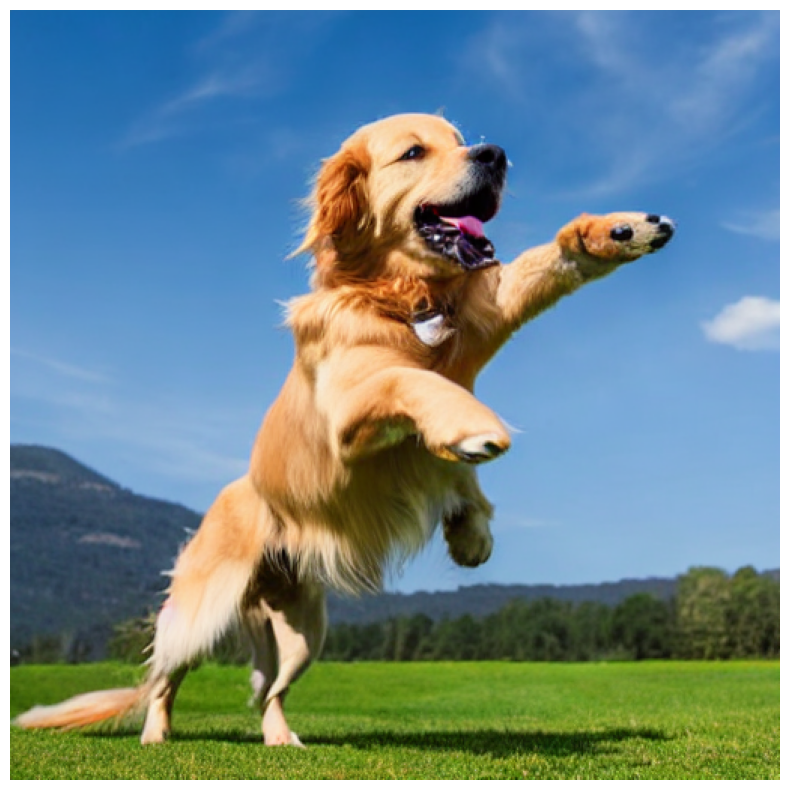

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load and display the image
img = mpimg.imread('generated_dog.png')  # or 'gan_generated_image.png'

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.show()

### Input / output representation

For both models, the input is text broken into tokens by a tokenizer and fed to the model. For
T5, the output is text decoded from the generated tokens; for Stable Diffusion, the output is an
image.

### Model architecture

T5 uses encoder and decoder blocks composed of multi-head attention, feed-forward networks, and
LayerNorm layers. Positional encodings inject information about token order. The encoder produces
learned token representations and the decoder generates tokens autoregressively; LayerNorm reduces
internal covariance shift.

Stable Diffusion uses a U-Net, self-attention layers, a VAE, and a CLIP text encoder. The U-Net
denoises latent representations over multiple steps, the CLIP text encoder aligns text and image
semantics to condition generation, and the VAE enables efficient processing in a lower-dimensional
latent space.

### Loss function

For T5, cross-entropy loss is used: it handles sequential data by treating text generation as a
token-classification problem, with ground-truth tokens fed during training. For Stable Diffusion,
the loss is the mean squared error between predicted and actual noise added to the latent
representations, modeling diffusion as a sequence of noise addition/removal steps.

### Training challenge

**T5 — exposure bias:** the model sees only ground-truth tokens during training but its own
predictions at inference. Mitigations include scheduled sampling (gradually mixing model
predictions with ground truth) and reinforcement learning from human feedback.

**Stable Diffusion — instability:** driven by a high-dimensional output space and long training
sequences (1000+ diffusion steps). Mitigations include latent diffusion (operating in compressed
VAE space), gradient clipping, and an exponential moving average (EMA) of model weights.

### Comparison

T5 suits text-to-text tasks (translation, question answering); Stable Diffusion suits text-to-image
generation. T5 is more interpretable — attention weights can reveal token importance and its output
space is human-readable text. Stable Diffusion is less efficient, requiring many U-Net evaluations
(50–100 steps) per image, though latent-space diffusion uses less compute than pixel-space methods.
T5 adapts well to new domains through quick fine-tuning; Stable Diffusion is harder to deploy due to
its larger memory footprint (VAE + U-Net + CLIP) and the need for real-time generation optimization
(e.g., distillation, TensorRT).